# InvestIQ — Multi-Horizon Stock Model (Step 1 & 2)

**Goal:** for each stock and each month-end, estimate the chance it **beats the market** over the next
1 / 3 / 6 / 12 months (and later 3 years). The market is the equal-weighted average of the same universe,
so the target is about *which company looks better*, not *did the whole market rise*.

**Data:** `ml/data/raw/nifty50_historical_data.csv` — 49 NIFTY 50 stocks, daily, 1999 → Jan 2026.

**Rules that make the evaluation honest**
- Features at a month-end use only prices up to that month-end.
- The file's fundamental columns (P/E, EPS, market cap, beta, 52-week high …) are a **present-day snapshot
  repeated on every historical row**, so they are dropped. Rolling versions are computed from prices instead.
- Testing is **walk-forward**: train on the past, predict the next year, repeat. Rows whose label overlaps
  the test year are purged from training.

Code: `ml/stock_model/prices.py` (clean), `panel.py` (features + targets), `walkforward.py` (train + evaluate).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ML_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ML_DIR))

from stock_model import prices, panel, walkforward as wf

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)

BLUE, MUTED, GRID = "#2a78d6", "#52514e", "#e4e3df"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]  # fixed categorical order
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": GRID, "axes.labelcolor": MUTED, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.prop_cycle": plt.cycler(color=SERIES),
})

## 1. Clean the price history

In [2]:
prices_df, report, saved_to = prices.build_clean_file()

breaks = report.pop("structural_breaks")
print(report)
print("saved ->", saved_to)
print("\nStructural breaks (history kept only after these dates):")
for ticker, day in breaks.items():
    print(f"  {ticker:15} {day}")

{'rows_in': 287310, 'tickers_in': 49, 'duplicates_dropped': 0, 'bad_close_dropped': 47, 'zero_volume_set_nan': 4398, 'glitch_bars_dropped': 32, 'rows_before_breaks_dropped': 7686, 'rows_out': 279545, 'tickers_out': 49, 'date_min': datetime.date(1999, 1, 1), 'date_max': datetime.date(2026, 1, 30)}
saved -> /Users/amit/Desktop/InvestIQ/ml/data/processed/nifty50_prices.csv

Structural breaks (history kept only after these dates):
  ADANIENT.NS     2004-06-28
  BAJAJ-AUTO.NS   2008-05-26
  BAJAJFINSV.NS   2008-05-26
  DRREDDY.NS      2001-10-15
  LT.NS           2004-05-19
  NESTLEIND.NS    2010-01-08
  TCS.NS          2004-05-06
  ULTRACEMCO.NS   2004-08-24
  WIPRO.NS        1999-09-27


Two different problems are handled separately:
- **Glitch bars** (a lone spike that reverses the next day) are dropped.
- **Structural breaks** (a level shift that persists, e.g. the 2008 Bajaj demerger or the TCS listing) —
  returns across them would be meaningless, so only the history *after* the break is kept for that stock.

In [3]:
coverage = prices.coverage_table(prices_df)
print("stocks:", len(coverage), "| rows:", len(prices_df))
print("calendar gaps > 7 days:", len(prices.trading_calendar_gaps(prices_df)))
coverage.nsmallest(5, "rows")

stocks: 49 | rows: 279545
calendar gaps > 7 days: 0


,ticker,sector,rows,start,end,missing_volume
19,HDFCLIFE.NS,Financials,2027,2017-11-17,2026-01-30,2
38,SBILIFE.NS,Financials,2059,2017-10-03,2026-01-30,2
30,LTIM.NS,IT,2355,2016-07-21,2026-01-30,5
12,COALINDIA.NS,Metals,3759,2010-11-04,2026-01-30,4
33,NESTLEIND.NS,FMCG,3966,2010-01-08,2026-01-30,4


## 2. Monthly panel: features and targets

In [4]:
panel_df, feature_cols = panel.build_monthly_panel(prices_df)

print(f"panel: {len(panel_df)} rows | {panel_df.ticker.nunique()} stocks | "
      f"{panel_df.date.min().date()} -> {panel_df.date.max().date()}")
print(f"features: {len(feature_cols)}")
panel_df[["date", "symbol", "sector", "ret_12m", "momentum_12_1", "rel_ret_3m",
          "dist_from_52w_high", "volatility_12m", "beta_12m", "fwd_excess_1M", "target_beat_1M"]].tail(4)

panel: 12910 rows | 49 stocks | 2000-01-31 -> 2026-01-30
features: 25


,date,symbol,sector,ret_12m,momentum_12_1,rel_ret_3m,dist_from_52w_high,volatility_12m,beta_12m,fwd_excess_1M,target_beat_1M
12906,2025-10-31,WIPRO,IT,-0.092859,-0.097759,-0.096635,-0.230829,0.016399,1.134785,0.022935,1
12907,2025-11-28,WIPRO,IT,-0.101864,-0.133754,-0.076507,-0.202513,0.015994,1.138685,0.048626,1
12908,2025-12-31,WIPRO,IT,-0.092950,-0.140321,0.033932,-0.158569,0.015943,1.160351,-0.061780,0
12909,2026-01-30,WIPRO,IT,-0.205527,-0.139280,0.004800,-0.223331,0.015936,1.203564,NaN,<NA>


In [5]:
balance = pd.DataFrame({
    horizon: {
        "labelled_rows": int(panel_df[f"target_beat_{horizon}"].notna().sum()),
        "beats_market": panel_df[f"target_beat_{horizon}"].mean(),
        "goes_up": panel_df[f"target_up_{horizon}"].mean(),
        "mean_fwd_return": panel_df[f"fwd_return_{horizon}"].mean(),
    }
    for horizon in panel.HORIZONS
}).T
balance.round(3)

,labelled_rows,beats_market,goes_up,mean_fwd_return
1M,12861.0,0.471,0.572,0.020
3M,12763.0,0.461,0.625,0.063
6M,12616.0,0.452,0.668,0.132
1Y,12322.0,0.425,0.727,0.284
3Y,11146.0,0.351,0.871,1.074


Fewer than half the stocks beat the equal-weighted market, and the share falls with the horizon
(a few big winners pull the average up). "Goes up" rises with the horizon simply because the market
drifts upward over time — which is exactly why the market-relative target is the more informative one.

### Leakage check

Recomputing the features from a price history truncated at a cut-off must not change any value
before that cut-off. If it does, a feature is peeking into the future.

In [6]:
cutoff = pd.Timestamp("2015-12-31")
truncated_panel, _ = panel.build_monthly_panel(prices_df[prices_df.date <= cutoff])

merged = panel_df.merge(truncated_panel, on=["date", "symbol"], suffixes=("", "_cut"))
numeric = [c for c in feature_cols if c != "sector"]
max_diff = max((merged[c] - merged[f"{c}_cut"]).abs().max() for c in numeric)

print(f"rows compared: {len(merged)}, max feature difference: {max_diff:.2e}")
assert max_diff < 1e-9, "Feature leakage detected"

rows compared: 7066, max feature difference: 2.64e-14


## 3. Walk-forward evaluation

For every test year from 2006 on: train on earlier data (minus a purge gap), keep the last 12 months for
early stopping, then predict that year. The model is compared with two naive baselines and judged on
whether its **ranking** works: do its top picks beat its bottom picks?

In [7]:
horizons = {"1M": 1, "3M": 3, "6M": 6, "1Y": 12}
results = {}

for label, months in horizons.items():
    target, forward = f"target_beat_{label}", f"fwd_excess_{label}"
    predictions, per_year = wf.walk_forward(panel_df, feature_cols, months, target, forward)
    monthly_rank = wf.rank_metrics(predictions, forward)

    results[label] = {
        "predictions": predictions,
        "per_year": per_year,
        "pooled": wf.classification_scores(predictions[target], predictions["probability"]),
        "baselines": wf.baseline_scores(panel_df, predictions, target),
        "monthly_rank": monthly_rank,
        "rank": wf.rank_summary(monthly_rank),
    }
    print(f"{label} done: {len(predictions)} predictions over {len(per_year)} years")

1M done: 11019 predictions over 20 years


3M done: 10921 predictions over 20 years


6M done: 10774 predictions over 20 years


1Y done: 10480 predictions over 20 years


In [8]:
summary = pd.DataFrame({
    label: {
        "model_auc": r["pooled"]["roc_auc"],
        "model_accuracy": r["pooled"]["accuracy"],
        "momentum_auc": r["baselines"].loc["momentum_rank", "roc_auc"],
        "mean_year_auc": r["per_year"]["roc_auc"].mean(),
        "years_auc_above_0.5": f'{(r["per_year"]["roc_auc"] > 0.5).sum()}/{len(r["per_year"])}',
        "mean_rank_ic": r["rank"]["mean_rank_ic"],
        "top_minus_bottom": r["rank"]["mean_top_minus_bottom"],
        "months_spread_positive": r["rank"]["share_spread_positive"],
    }
    for label, r in results.items()
}).T
summary.round(4)

,model_auc,model_accuracy,momentum_auc,mean_year_auc,years_auc_above_0.5,mean_rank_ic,top_minus_bottom,months_spread_positive
1M,0.505428,0.521644,0.509725,0.503207,11/20,-0.001729,-0.000894,0.508333
3M,0.499799,0.534566,0.515399,0.504172,12/20,0.010713,0.005286,0.512605
6M,0.486825,0.538983,0.512129,0.499243,10/20,0.011769,0.025732,0.553191
1Y,0.532044,0.563263,0.505268,0.526495,12/20,0.037089,0.077664,0.580786


**How to read this**
- `model_auc` 0.50 = coin flip. Anything under ~0.52 is noise.
- `momentum_auc` is the "recent winners keep winning" rule — the model must beat it to add value.
- `top_minus_bottom` is the average return of the 10 highest-ranked stocks minus the 10 lowest, over the horizon.
- `months_spread_positive` is how often that spread was positive; ~0.50 means the ranking is not reliable.

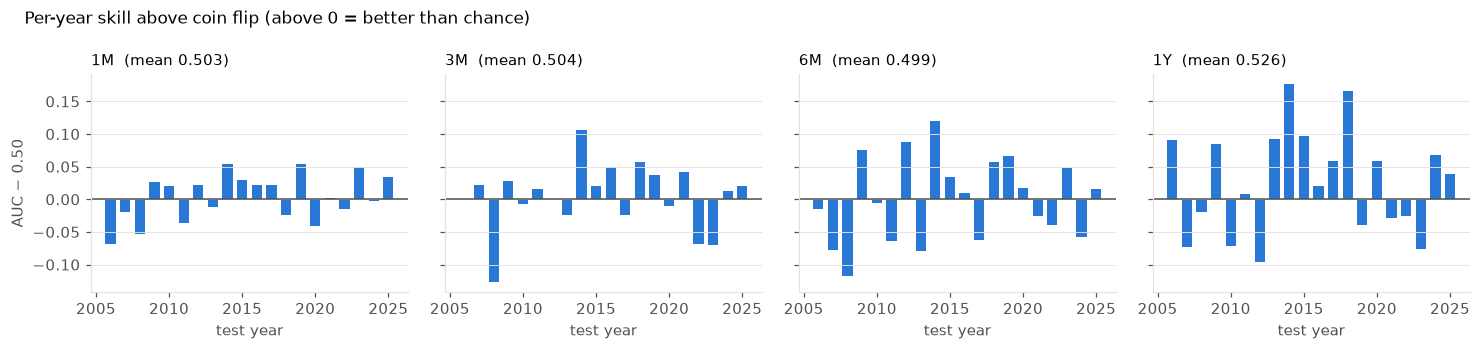

In [9]:
fig, axes = plt.subplots(1, len(results), figsize=(3.4 * len(results), 3.2), sharey=True)

for ax, (label, r) in zip(axes, results.items()):
    per_year = r["per_year"]
    ax.bar(per_year["year"], per_year["roc_auc"] - 0.5, color=BLUE, width=0.7)
    ax.axhline(0, color=MUTED, linewidth=1)
    ax.set_title(f"{label}  (mean {per_year['roc_auc'].mean():.3f})", loc="left", fontsize=10)
    ax.set_xlabel("test year")
    ax.grid(axis="x", visible=False)

axes[0].set_ylabel("AUC − 0.50")
fig.suptitle("Per-year skill above coin flip (above 0 = better than chance)", x=0.02, ha="left", fontsize=11)
plt.tight_layout()
plt.show()

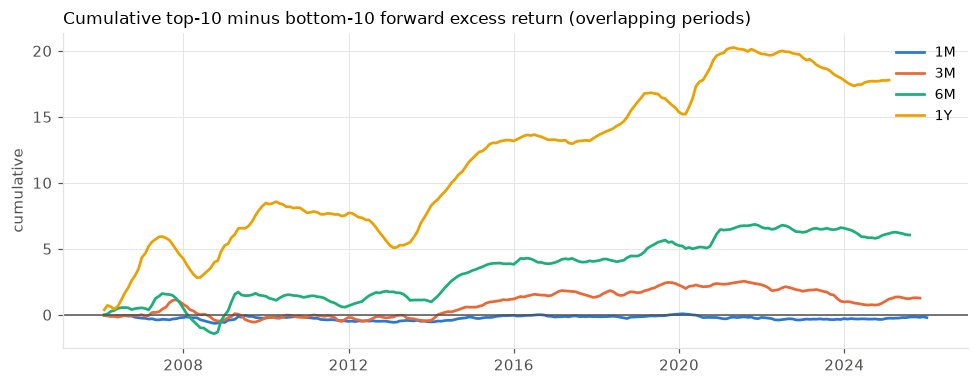

In [10]:
fig, ax = plt.subplots(figsize=(9, 3.6))

for label, r in results.items():
    monthly = r["monthly_rank"].dropna(subset=["top_minus_bottom"]).sort_values("date")
    ax.plot(monthly["date"], monthly["top_minus_bottom"].cumsum(), linewidth=1.8, label=label)

ax.axhline(0, color=MUTED, linewidth=1)
ax.set_title("Cumulative top-10 minus bottom-10 forward excess return (overlapping periods)",
             loc="left", fontsize=11)
ax.set_ylabel("cumulative")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

The horizons overlap (a 12-month label covers the next 12 months), so these lines are *not* portfolio
returns and must not be read as profit. They only show whether the ranking points the right way over time.

## 4. Which features does the model use?

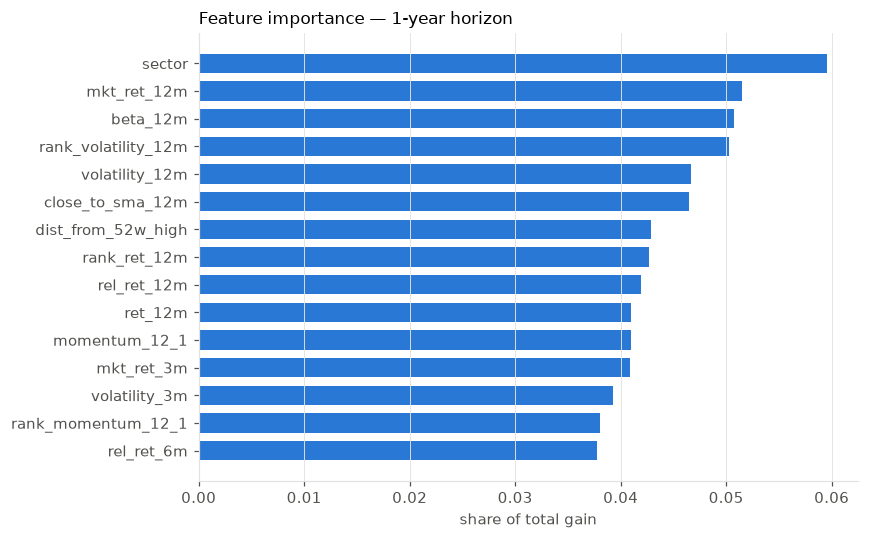

,feature,gain,gain_share
0,sector,10.8326,0.0595
1,mkt_ret_12m,9.3811,0.0515
2,beta_12m,9.2314,0.0507
3,rank_volatility_12m,9.1571,0.0503
4,volatility_12m,8.4990,0.0467
5,close_to_sma_12m,8.4626,0.0465
6,dist_from_52w_high,7.7984,0.0428
7,rank_ret_12m,7.7687,0.0427
8,rel_ret_12m,7.6260,0.0419
9,ret_12m,7.4656,0.0410


In [11]:
importance = wf.feature_importance(panel_df, feature_cols, "target_beat_1Y", 12)

top = importance.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top["feature"], top["gain_share"], color=BLUE, height=0.7)
ax.grid(axis="y", visible=False)
ax.set_xlabel("share of total gain")
ax.set_title("Feature importance — 1-year horizon", loc="left", fontsize=11)
plt.tight_layout()
plt.show()

importance.head(10).round(4)

## 5. Findings

1. **Short horizons show no skill.** For 1, 3 and 6 months the AUC sits at ~0.50 and the top-ranked stocks
   do not beat the bottom-ranked ones. With price features only, on 49 large-cap stocks, monthly
   market-relative direction is essentially unpredictable here. The momentum baseline is equally flat.
2. **The 1-year horizon shows a weak but consistent signal** — a positive rank correlation and a positive
   top-minus-bottom spread in most months. It is weak, and the 12-month periods overlap heavily, so the
   effective number of independent observations is far smaller than the row count suggests.
3. **The pipeline itself is verified:** the leakage check passes, training is purged, and every year is
   tested out of sample against naive baselines.
4. **What's missing is information, not modelling.** The model currently sees only price history. The
   things a research platform would actually use — earnings growth, margins, ROE, debt, valuation —
   are not in this dataset.

## 6. Next steps (in order)

1. **Fundamentals with real publication dates** (NSE XBRL result filings): growth, margins, ROE/ROCE, debt,
   and valuations computed against price. This is the single biggest gap.
2. **Wider universe**: NIFTY 50 is 49 large caps that are in the index *today* — a survivorship bias that
   flatters long horizons. Adding mid-caps and former constituents both fixes the bias and multiplies the data.
3. **Sector-relative targets**: "beats its sector" is often more learnable than "beats the market".
4. **Then extend to 3 years**, once the bias above is addressed — otherwise the long-horizon result is
   measuring index membership, not company quality.